In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import uproot
import awkward as ak
import tabulate as tab
import glob
import h5py
from tqdm import tqdm

from scipy.signal import find_peaks


# How to read raw data files

In [2]:
def read_root_files(filepath, cosmics=False):
    file = uproot.open(filepath)
    print(file.keys())
    analyszer = 'PNSCRPanalyzercosmics' if cosmics else 'PNSCRPanalyzerflashes1'
    evts = uproot.open(f"{filepath}:{analyszer}/Event")
    akw = evts.arrays(filter_name=evts.keys(), library="ak")
    return akw

def get_info(akw, display=False):
    Nevents    = len(akw['waveformsADC'])
    TrigWindow = len(akw['waveformsADC'][0][0])
    Nchannels  = len(akw['waveformsADC'][0])
    maxima = []
    for chID in range(0, Nchannels):
        maxima.append(ak.max( akw['waveformsADC'][:][chID]) )
    if display:
        print(' trigger reccords', Nevents)
        print(' trigger window', TrigWindow)
        print(' number of channels', Nchannels)
        print(' max height', int(np.max(maxima)) )
    return Nevents, TrigWindow, Nchannels, maxima


In [3]:
# path to the file
cernbox = '/Users/emiliebertholet/cernbox/coldbox_data'
directory = f'{cernbox}/anaCRP_files/raw_files'
filename = 'ana_pns_r25036_small_0_7.root'


In [4]:
cosmics = False
if 'cosmics' in filename: cosmics = True
akw = read_root_files(f'{directory}/{filename}', cosmics=cosmics)

['PNSCRPanalyzerflashes1;1', 'PNSCRPanalyzerflashes1/Event;87', 'PNSCRPanalyzerflashes1/Event;86']


In [5]:
_, _, _, _ = get_info(akw, display=True)

 trigger reccords 2324
 trigger window 65600
 number of channels 12
 max height 16383


In [6]:
# akw

# File Organization

The file contains many variables corresponding to the readout of different detectors. For the moment, we focus on ```waveformsADC```, which stores the digitized output of the xARAPUCA modules (SiPM-based light detectors).

### Waveform Format

The waveforms are electrical pulses. Because they are digitized, they are recorded as ADC counts vs. time ticks, rather than voltage vs. physical time.

- 1 ADC count corresponds to a specific voltage increment.

- 1 time tick corresponds to a fixed time interval.

In the ColdBox there are several xARAPUCA modules. Each module provides 2 readout channels. At first, we want to look at 1 channel at a time.

The strucutre of the data for one specific channel is an array of arrays:

### Data Structure

For a given channel, the waveform data is stored as a list of arrays, where each array corresponds to one trigger record.

```
[
    [ADC_0, ADC_1, ADC_2, ..., ADC_N],   # trigger record 0
    [ADC_0, ADC_1, ADC_2, ..., ADC_N],   # trigger record 1
    ...
]

```

A trigger record correspond to an acquisition window of a fixed number of time ticks.






In [7]:
raw_wfs = akw['waveformsADC']
raw_wfs

<Array [[[1.7e+03, ..., 1.72e+03], ...], ...] type='2324 * var * var * float32'>

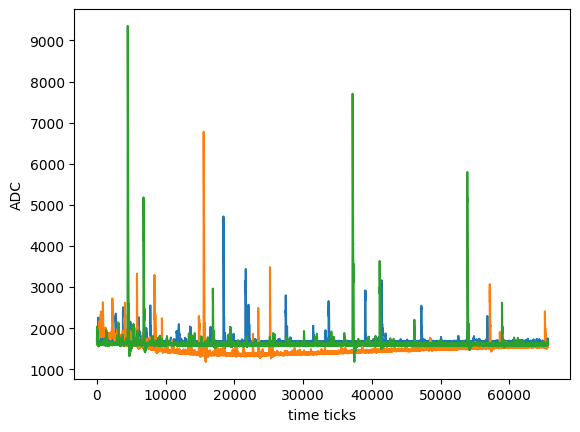

In [8]:
# several triggger records
chID = 0
triggerRecs = [0, 10, 15]
for i in triggerRecs:
    plt.plot(raw_wfs[i][chID])
plt.xlabel('time ticks')
plt.ylabel('ADC');

In [9]:
## check trigger length 
chID = 0
lengths = ak.to_numpy( ak.num(raw_wfs[:, chID]) )
values, counts = np.unique(lengths, return_counts=True)
print(values, counts)
print(counts)

[65536 65600] [  26 2298]
[  26 2298]


In [10]:
## TODO: add also the cases where the lenght of the trigger record is smaller
arr = [ak.to_numpy(raw_wfs[i][chID]) for i in range(21) if len(ak.to_numpy(raw_wfs[i][chID])) == 65600]
N = len(arr)
print(N)

# np.savez(
#     f"trig_{N}_chID_{chID}.npz",
#     X=arr,
# )

20


In [11]:
## TODO: plot some trigRecs by channels

# Find peaks

In [12]:
## algo
def estimate_baseline_drift(record, chunk=2000, q=10):
    """
    Baseline proxy per chunk: q-th percentile (q=10 works well when pulses are positive-going).
    Returns:
      baseline_chunks: array of per-chunk baseline estimates
      drift_ptp: peak-to-peak baseline variation across record
      drift_std: std of baseline across chunks
    """
    n = len(record)
    baselines = []

    for start in range(0, n, chunk):
        seg = record[start:start + chunk]
        baselines.append(np.percentile(seg, q))

    baselines = np.asarray(baselines, dtype=np.float64)

    drift_ptp = float(np.ptp(baselines))  
    drift_std = float(np.std(baselines))  

    return baselines, drift_ptp, drift_std

def extract_peaks_from_records(
    X,
    *,
    # Peak detection (baseline-subtracted, in ADC counts)
    height=80.0,
    prominence=150.0,
    distance=150,

    # Baseline estimation for peak finding
    baseline_chunk=2000,
    baseline_q=10,

    # Drift flagging threshold (ADC counts)
    drift_ptp_threshold=200.0,
):
    """
    Args:
      X: array (N_records, N_samples)
    Returns:
      results: list of dicts, one per record with:
        - peaks_idx: (N_peaks,) indices in original trigger record
        - peaks_height: (N_peaks,) baseline-subtracted peak heights
        - baseline_trace: (N_samples,) piecewise-linear baseline estimate (qth percentile per chunk)
        - baseline_chunks: (N_chunks,) raw chunk baselines
        - drift_ptp, drift_std
        - flagged_drift: bool
    """
    results = []
    n_records, n_samples = X.shape

    for r in range(n_records):
        rec = X[r].astype(np.float64, copy=False)

        # Chunk baseline estimates (robust to pulses if q is low)
        baseline_chunks, drift_ptp, drift_std = estimate_baseline_drift(
            rec, chunk=baseline_chunk, q=baseline_q
        )

        # Build a baseline trace by interpolating chunk baselines to all samples
        centers = np.arange(len(baseline_chunks)) * baseline_chunk + (baseline_chunk - 1) / 2
        centers = np.clip(centers, 0, n_samples - 1)
        idx = np.arange(n_samples)
        baseline_trace = np.interp(idx, centers, baseline_chunks)

        # Baseline-subtracted waveform for peak finding
        y = rec - baseline_trace

        # Peak detection
        peaks_idx, props = find_peaks(
            y,
            height=height,
            prominence=prominence,
            distance=distance,
        )

        peaks_height = props["peak_heights"]  # same length as peaks_idx

        results.append({
            "record_index": r,
            "peaks_idx": peaks_idx.astype(np.int32),
            "peaks_height": peaks_height.astype(np.float32),
            "peaks_prominence": props["prominences"].astype(np.float32),
            "baseline_chunks": baseline_chunks.astype(np.float32),
            "baseline_trace": baseline_trace.astype(np.float32),
            "drift_ptp": drift_ptp,
            "drift_std": drift_std,
            "flagged_drift": bool(drift_ptp > drift_ptp_threshold),
        })

    return results

In [23]:
## plots

def plot_record_qc_from_result(
    X,
    result: dict,
    *,
    pre: int = 40,
    post: int = 216,
    max_pulses_to_plot: int | None = 200,
    show_baseline_overlay: bool = True,
):
    """
    QC plot driven by a single 'result' dict (one record entry from `results`).
    Uses:
      - result["record_index"]
      - result["baseline_trace"]
      - result["peaks_idx"]
      - drift stats + flagged status

    Returns:
      windows: (N_valid_peaks, pre+post) baseline-subtracted windows
      valid_peaks: indices in original record of peaks actually windowed (not near edges)
    """
    i = int(result["record_index"])
    rec = X[i].astype(np.float64, copy=False)

    baseline = np.asarray(result["baseline_trace"], dtype=np.float64)
    peaks = np.asarray(result["peaks_idx"], dtype=np.int64)

    # Baseline-subtracted waveform
    y = rec - baseline

    # Extract windows around peaks
    win_len = pre + post
    windows = []
    valid_peaks = []
    for p in peaks:
        start = p - pre
        end = p + post
        if start < 0 or end > len(y):
            continue
        windows.append(y[start:end])
        valid_peaks.append(p)

    windows = np.asarray(windows, dtype=np.float64)
    valid_peaks = np.asarray(valid_peaks, dtype=np.int32)

    # Cap pulses plotted for readability
    windows_plot = windows
    if max_pulses_to_plot is not None and len(windows) > max_pulses_to_plot:
        idx = np.random.choice(len(windows), size=max_pulses_to_plot, replace=False)
        windows_plot = windows[idx]

    # ---- Plot layout ----
    fig = plt.figure(figsize=(16, 6), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax_raw = fig.add_subplot(gs[0, 0])
    ax_sub = fig.add_subplot(gs[1, 0], sharex=ax_raw)
    ax_win = fig.add_subplot(gs[:, 1])

    # A) Raw waveform (+ baseline overlay)
    ax_raw.plot(rec, linewidth=1)
    if show_baseline_overlay:
        ax_raw.plot(baseline, linewidth=1.5)
    ax_raw.set_title(
        f"Record {i}: raw waveform" + (" (baseline overlay)" if show_baseline_overlay else "")
    )
    ax_raw.set_ylabel("ADC")
    ax_raw.grid(True, alpha=0.25)

    # Info box (pulled from dict)
    drift_ptp = float(result.get("drift_ptp", np.nan))
    drift_std = float(result.get("drift_std", np.nan))
    flagged = bool(result.get("flagged_drift", False))

    info = (
        f"peaks detected: {len(peaks)}\n"
        f"peaks windowed: {len(valid_peaks)}\n"
        f"drift_ptp: {drift_ptp:.1f}\n"
        f"drift_std: {drift_std:.1f}\n"
        f"flagged: {flagged}"
    )
    ax_raw.text(
        0.01, 0.98, info,
        transform=ax_raw.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", alpha=0.85),
        fontsize=10
    )

    # B) Baseline-subtracted + peaks
    ax_sub.plot(y, linewidth=1)
    if len(valid_peaks) > 0:
        ax_sub.scatter(valid_peaks, y[valid_peaks], marker="x", s=40)
    ax_sub.set_title("Baseline-subtracted waveform with detected peaks (✕)")
    ax_sub.set_xlabel("Sample index")
    ax_sub.set_ylabel("ADC (subtracted)")
    ax_sub.grid(True, alpha=0.25)

    # C) Superimposed windows (aligned)
    if len(windows_plot) > 0:
        t = np.arange(win_len) - pre
        ax_win.plot(t, windows_plot.T, linewidth=0.8, alpha=0.35)
        ax_win.axvline(0, linestyle="--", linewidth=1)
    ax_win.set_title(f"Extracted pulse windows superimposed (n={len(windows_plot)})")
    ax_win.set_xlabel("Samples relative to peak (0 = peak)")
    ax_win.set_ylabel("ADC (subtracted)")
    ax_win.grid(True, alpha=0.25)

    plt.show()
    return windows, valid_peaks


In [19]:
# ---- Example usage ----
if __name__ == "__main__":
    path = "trig_20_chID_1.npz"
    data = np.load(path)
    X = data["X"]  # shape (20, 65600)

    results = extract_peaks_from_records(
        X,
        height=80.0,
        prominence=150.0,
        distance=150,
        baseline_chunk=2000,
        baseline_q=10,
        drift_ptp_threshold=200.0,
    )

    # Quick summary
    for r in results:
        n_peaks = len(r["peaks_idx"])
        flag = "⚠️ DRIFT" if r["flagged_drift"] else "ok"
        print(
            f"rec {r['record_index']:02d}: peaks={n_peaks:3d}  "
            f"drift_ptp={r['drift_ptp']:.1f}  ({flag})"
        )

    # # Example: access peak positions for record 0
    # print()
    # print(results[0]["peaks_idx"])

rec 00: peaks= 19  drift_ptp=9.0  (ok)
rec 01: peaks= 25  drift_ptp=112.1  (ok)
rec 02: peaks= 17  drift_ptp=102.0  (ok)
rec 03: peaks= 21  drift_ptp=9.0  (ok)
rec 04: peaks= 17  drift_ptp=11.0  (ok)
rec 05: peaks= 18  drift_ptp=120.2  (ok)
rec 06: peaks= 14  drift_ptp=14.0  (ok)
rec 07: peaks= 18  drift_ptp=9.0  (ok)
rec 08: peaks= 21  drift_ptp=23.0  (ok)
rec 09: peaks= 26  drift_ptp=65.1  (ok)
rec 10: peaks= 26  drift_ptp=184.0  (ok)
rec 11: peaks= 19  drift_ptp=20.0  (ok)
rec 12: peaks= 24  drift_ptp=93.0  (ok)
rec 13: peaks= 21  drift_ptp=74.1  (ok)
rec 14: peaks= 18  drift_ptp=48.1  (ok)
rec 15: peaks= 23  drift_ptp=19.0  (ok)
rec 16: peaks= 30  drift_ptp=47.0  (ok)
rec 17: peaks= 19  drift_ptp=8.0  (ok)
rec 18: peaks= 20  drift_ptp=28.0  (ok)
rec 19: peaks= 29  drift_ptp=32.1  (ok)


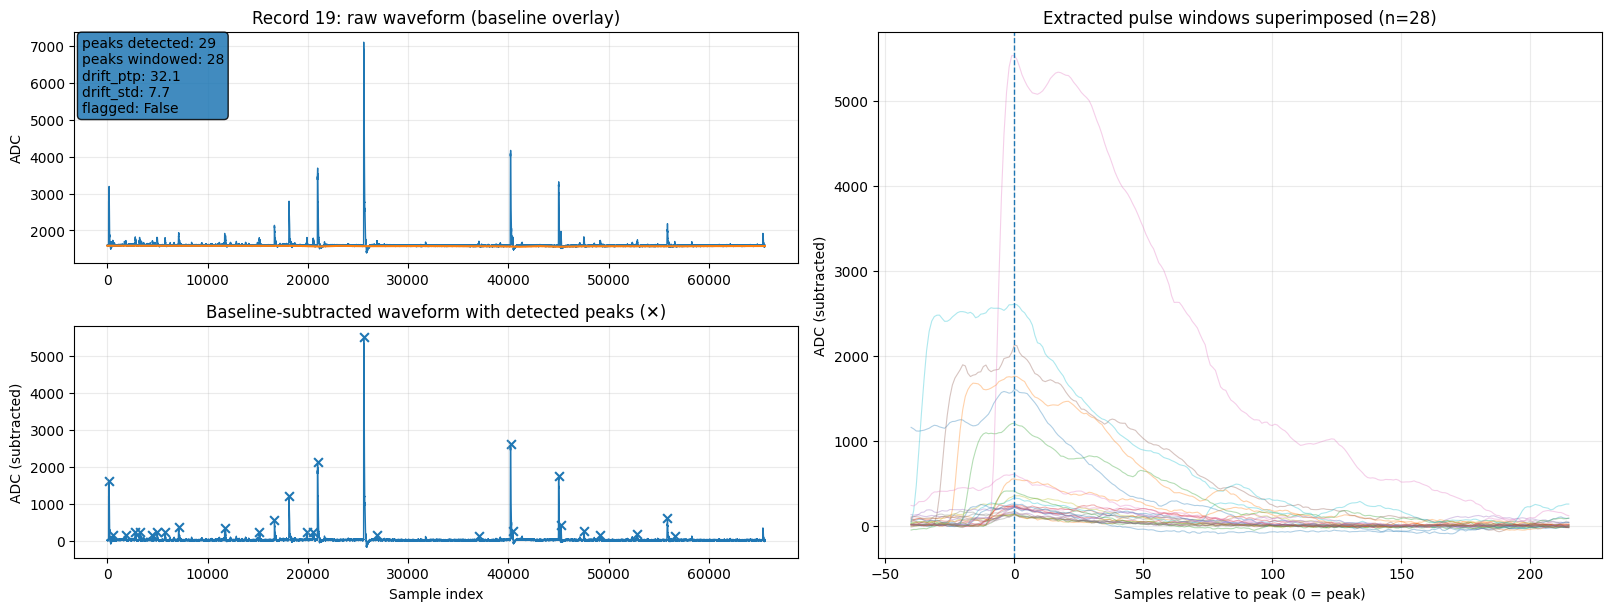

In [26]:
windows, peak_positions = plot_record_qc_from_result(
    X,
    results[19],
    pre=40,
    post=216
)